In [231]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
%matplotlib inline

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# TorchVision
import torchvision.transforms.v2 as v2
from torchvision.models import inception_v3, resnet50, efficientnet_b4, EfficientNet_B4_Weights, ResNet50_Weights, Inception_V3_Weights, VGG19_BN_Weights, vgg19_bn
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# Data utilities
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split, Dataset
from tqdm import tqdm

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [232]:
MAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face-Age-Gender Dataset\face_dataset"
TRAIN_PATH = os.path.join(MAIN_PATH,"train")
TEST_PATH = os.path.join(MAIN_PATH,"test")

IMG_SIZE = 380

EPOCHS = 10
TRAIN_BATCH_SIZE = 4
TEST_BATCH_SIZE = 2
PATIENCE = 5

LR = 1e-4

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 0

small_df = pd.read_csv(r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face Age Dataset\age_detection.csv")
small_df

,file,age,split
0,train/18-20/0.jpg,18-20,train
1,train/18-20/1.jpg,18-20,train
2,train/18-20/2.jpg,18-20,train
3,train/18-20/3.jpg,18-20,train
4,train/18-20/4.jpg,18-20,train
...,...,...,...
145,test/51-60/25.jpg,51-60,test
146,test/51-60/26.jpg,51-60,test
147,test/51-60/27.jpg,51-60,test
148,test/51-60/28.jpg,51-60,test


In [233]:
train_df = pd.read_csv(os.path.join(MAIN_PATH,"train.csv"))
test_df = pd.read_csv(os.path.join(MAIN_PATH,"test.csv"))
train_df

,id,full_path,gender,age
0,0,train/00000.jpg,1,66
1,1,train/00001.jpg,1,53
2,2,train/00002.jpg,1,20
3,3,train/00003.jpg,1,32
4,4,train/00004.jpg,1,21
...,...,...,...,...
34703,34703,train/34703.jpg,1,32
34704,34704,train/34704.jpg,1,28
34705,34705,train/34705.jpg,1,25
34706,34706,train/34706.jpg,1,19


In [234]:
test_df

,id,full_path
0,0,test/00000.jpg
1,1,test/00001.jpg
2,2,test/00002.jpg
3,3,test/00003.jpg
4,4,test/00004.jpg
...,...,...
8672,8672,test/08672.jpg
8673,8673,test/08673.jpg
8674,8674,test/08674.jpg
8675,8675,test/08675.jpg


In [235]:
train_df["age"].describe()

count    34708.000000
mean        37.346692
std         16.587891
min          1.000000
25%         25.000000
50%         32.000000
75%         48.000000
max        100.000000
Name: age, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1bde3feae90>,
 'caps': [<matplotlib.lines.Line2D at 0x1bde3feb110>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bde3feac10>],
 'medians': [<matplotlib.lines.Line2D at 0x1bde33e7d90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1bde33e7ed0>],
 'means': []}

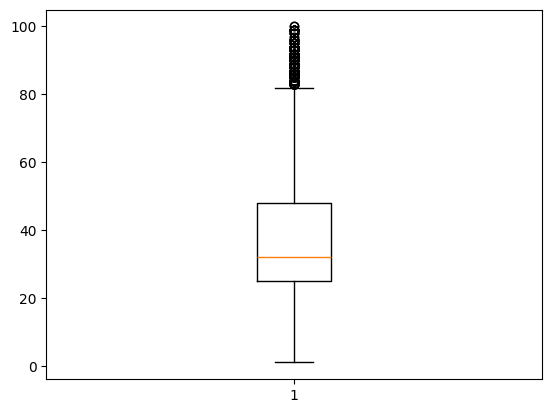

In [237]:
plt.boxplot(train_df['age'])

In [ ]:
labels = set(small_df["age"].values)
labels

{'18-20', '21-30', '31-40', '41-50', '51-60'}

In [ ]:
small_df['age'].value_counts()

age
18-20    30
21-30    30
31-40    30
41-50    30
51-60    30
Name: count, dtype: int64

In [ ]:
small_df['split'].value_counts()

split
train    125
test      25
Name: count, dtype: int64

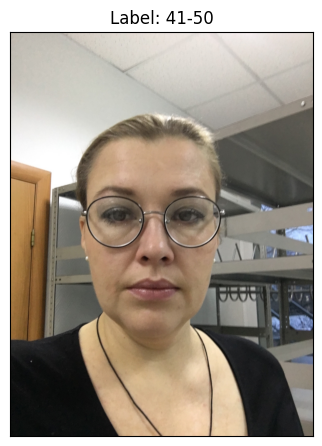

In [ ]:
def show_img():
    img_path = np.random.choice(small_df["file"].values)
    plt.imshow(plt.imread(os.path.join(MAIN_PATH,img_path)))
    plt.title(f"Label: {img_path.split('/')[1]}")
    plt.tight_layout()
    plt.yticks([])
    plt.xticks([])
    plt.show()

show_img()

In [217]:
def get_transforms(size=IMG_SIZE, apply_on_train=False):
    """
    Return a transform pipeline for the given split.

    Parameters
    ----------
    size           : int  — target image size (default 224)
    apply_on_train : bool — whether to include data augmentation
    """
    base = [
        v2.Resize((size, size)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]

    augmentation = [
        # v2.RandomHorizontalFlip(),
        # v2.RandomRotation(15),
        # v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        # v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    ]

    tail = [
        v2.Normalize(MEAN, STD),
    ]

    if apply_on_train:
        return v2.Compose(base + augmentation + tail)
    return v2.Compose(base + tail)


In [218]:
train_ds = ImageFolder(TRAIN_PATH,get_transforms(224,True))
test_ds = ImageFolder(TEST_PATH,get_transforms(224))

In [219]:
train_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [220]:
test_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [221]:
train_ds.classes

['18-20', '21-30', '31-40', '41-50', '51-60']

In [222]:
len(train_ds)

250

In [223]:
len(test_ds)

25

In [224]:
train_dl = DataLoader(train_ds,TRAIN_BATCH_SIZE,True,num_workers=NUM_WORKERS,pin_memory=True)
test_dl = DataLoader(test_ds,TEST_BATCH_SIZE,False,num_workers=NUM_WORKERS,pin_memory=True)

In [225]:
def denorm(imgs):
    mean = torch.tensor(MEAN).view(1, 3, 1, 1)
    std = torch.tensor(STD).view(1, 3, 1, 1)
    return imgs * std + mean

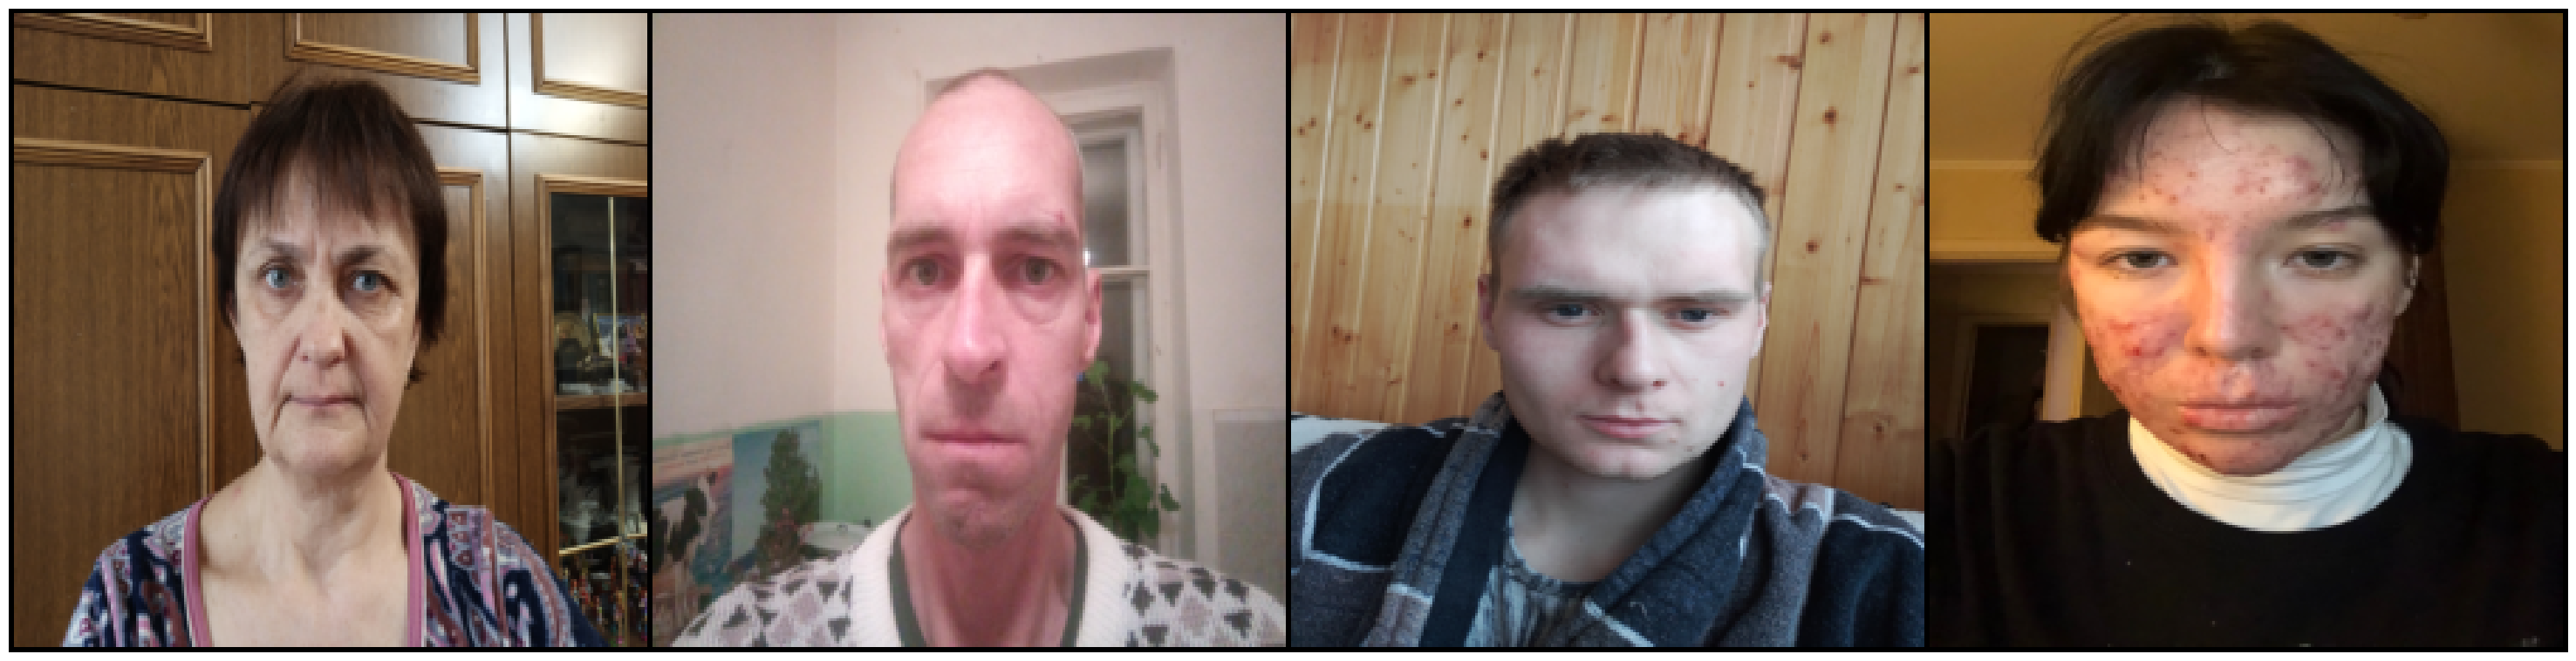

In [226]:
def show_grid_images(dataloader):
    imgs,labels = next(iter(dataloader))
    plt.figure(figsize=(30, 30))
    plt.imshow(make_grid(denorm(imgs),nrow=8).permute(1,2,0))
    plt.tight_layout()
    plt.axis('off')
    plt.show()

show_grid_images(train_dl)